# LULUCF v100 — two sets of maps
TODO: LULUCF gross emissions components (actual version is made in LULUCF mapping script, so this can be removed from here)

TODO: LULUCF gross emissions and removals distribution curves. Code is currently messy and should be cleaned up. 
Also, it should be combined with the code that actually calculates the curves (this currently uses a csv of the curves created by a separate script but they should be consolidated). 

TODO: Also, Gini coefficients are recalculated here rather than being reused from the original calculation of the curves. When this is combined with the curve calculation notebook,
the Gini coefficients won't need to be recalculated anymore.

In [14]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from pathlib import Path
from pyproj import Transformer
import textwrap
from datetime import datetime
import os as _os
import sys
from matplotlib import font_manager as _fmgr

_hb = _os.path.abspath("fonts/Helvetica-Bold.ttf")
if not _os.path.exists(_hb):
    _os.makedirs("fonts", exist_ok=True)
    _mac_path = "/System/Library/Fonts/Helvetica.ttc"
    if _os.path.exists(_mac_path):
        from fontTools.ttLib import TTCollection as _TTC
        _TTC(_mac_path).fonts[1].save(_hb)
        _fmgr.fontManager.addfont(_hb)
_fmgr.fontManager.addfont(_hb) if _os.path.exists(_hb) else None
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["font.size"] = 7

from matplotlib.offsetbox import TextArea, DrawingArea, HPacker, VPacker, AnchoredOffsetbox
from matplotlib.patches import Rectangle

def top_legend(ax, colors, labels, title, sw=None, fs=None, sep=None, rowsep=None,
               loc="center left", bbox_to_anchor=(0.02, 0.5)):
    """Legend with each colour swatch top-aligned to its (multi-line) label; scales with font size."""
    if fs is None: fs = mpl.rcParams["font.size"]
    if sw is None: sw = fs
    if sep is None: sep = fs * 0.6
    if rowsep is None: rowsep = fs * 0.8
    rows = []
    for c, lab in zip(colors, labels):
        da = DrawingArea(sw, sw, 0, 0)
        da.add_artist(Rectangle((0, 0), sw, sw, facecolor=c, edgecolor="none"))
        rows.append(HPacker(children=[da, TextArea(lab, textprops=dict(fontsize=fs))],
                            align="top", pad=0, sep=sep))
    head = TextArea(title, textprops=dict(fontsize=fs, fontweight="bold"))
    box = VPacker(children=[head] + rows, align="left", pad=0, sep=rowsep)
    ax.add_artist(AnchoredOffsetbox(loc=loc, child=box, pad=0, borderpad=0,
                                    frameon=False, bbox_to_anchor=bbox_to_anchor,
                                    bbox_transform=ax.transAxes))

In [3]:
# --- Config ----------------------------------------------------------------
ROBINSON = "ESRI:54030"

# Source rasters: local copies in data/ (Robinson ESRI:54030, float32, nodata=0, values 0-100).
# Originals live READ-ONLY on S3 under .../global_display_jpegs/.
RASTER_DIR = '/mnt/c/GIS/AFOLU_flux_model/LULUCF/4x4km_aggregated_maps/LULUCF_totals/LULUCF_version_1_0_0_standard__global__veg_v1_0_5__org_soil_v1_0_1__min_soil_v1_0_1/'
PANELS = [
    {"key": "veg", "letter": "a", "name": "Vegetation",
     "file": "pct_veg_gross_emis_of_LULUCF_gross_emis__1_0_5__organic_soil_v1_0_1__mineral_soil_v1_0_1_reproj.tif"},
    {"key": "org", "letter": "b", "name": "Organic soil",
     "file": "pct_org_soil_emis_of_LULUCF_gross_emis__1_0_5__organic_soil_v1_0_1__mineral_soil_v1_0_1_reproj.tif"},
    {"key": "min", "letter": "c", "name": "Mineral soil",
     "file": "pct_min_soil_loss_of_LULUCF_gross_emis__1_0_5__organic_soil_v1_0_1__mineral_soil_v1_0_1_reproj.tif"},
]
COUNTRIES_SHP = '/mnt/c/GIS/AFOLU_flux_model/LULUCF/4x4km_aggregated_maps/world-administrative-boundaries_simple__20250102.shp'

# 6 emission-fraction bins; colours sampled from the reference figure (light -> dark)
BIN_EDGES  = [30, 50, 70, 85, 95]                                   # interior edges
BIN_LABELS = [">0\u201330%", "30\u201350%", "50\u201370%", "70\u201385%", "85\u201395%", "95\u2013100%"]
BIN_COLORS = ["#fef0eb", "#fdc3ca", "#fe94b6", "#de3fa0", "#98017c", "#4a016c"]

OCEAN  = "#ffffff"   # white ocean / background
LAND   = "#ececec"   # light-grey land under no-data
BORDER = "#bdbdbd"   # country boundary lines
FRAME  = "#1a1a1a"   # bounding-box / panel frame

DECIMATE = 2         # read at 1/DECIMATE resolution for the figure
FIG_W_IN = 180 / 25.4   # 180 mm export width (inches)

In [15]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu
from src.utilities.create_cluster import create_cluster as cc_create_cluster

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

In [17]:
# LULUCF outputs (local copy of the parquet lives in ./data)
LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')
LULUCF_zonal_stats_folder

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1')

In [19]:
# Folder where figures go
LULUCF_zonal_stats_folder_figures = Path(f'{LULUCF_zonal_stats_folder}/figures/')
_os.makedirs(LULUCF_zonal_stats_folder_figures, exist_ok=True)
LULUCF_zonal_stats_folder_figures

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1/figures')

In [4]:
# --- Load once (local data/ rasters; cached in these globals) ---
def load_raster(path, decimate=DECIMATE):
    """Read a Robinson display raster (decimated) -> (values 0-100, NaN nodata, extent)."""
    with rasterio.open(path) as s:
        oh, ow = s.height // decimate, s.width // decimate
        arr = s.read(1, out_shape=(1, oh, ow), resampling=Resampling.nearest).astype("float32")
        nd, b = s.nodata, s.bounds
        extent = (b.left, b.right, b.bottom, b.top)
    if nd is not None:
        arr[arr == nd] = np.nan
    arr[arr <= 0] = np.nan                                   # 0 = no data / not shown
    return arr, extent

RASTERS = {p["key"]: load_raster(f"{RASTER_DIR}/{p['file']}") for p in PANELS}
WORLD = gpd.read_file(COUNTRIES_SHP).to_crs(ROBINSON)
for p in PANELS:
    print("loaded", p["key"], "| extent", [round(v) for v in RASTERS[p["key"]][1]])
print("countries:", len(WORLD))

loaded veg | extent [-17005833, 17002959, -6336626, 8102470]
loaded org | extent [-17005833, 17002959, -6336626, 8102470]
loaded min | extent [-17005833, 17002959, -6336626, 8102470]
countries: 231


Three stacked Robinson (`ESRI:54030`) world maps of the **fraction of gross LULUCF emissions** from vegetation (a), organic soil (b) and mineral soil (c).

Reads the display rasters **read-only from S3** and GADM country boundaries from `data/`. White ocean, light-grey land under no-data, country boundaries + the data on top.

## Figure 1- emissions components

saved LULUCF100_maps__fig1_components.png
saved LULUCF100_maps__fig1_components_gradient.png
saved LULUCF100_maps__fig1_components_zoom.png
saved LULUCF100_maps__fig1_components_gradient_zoom.png


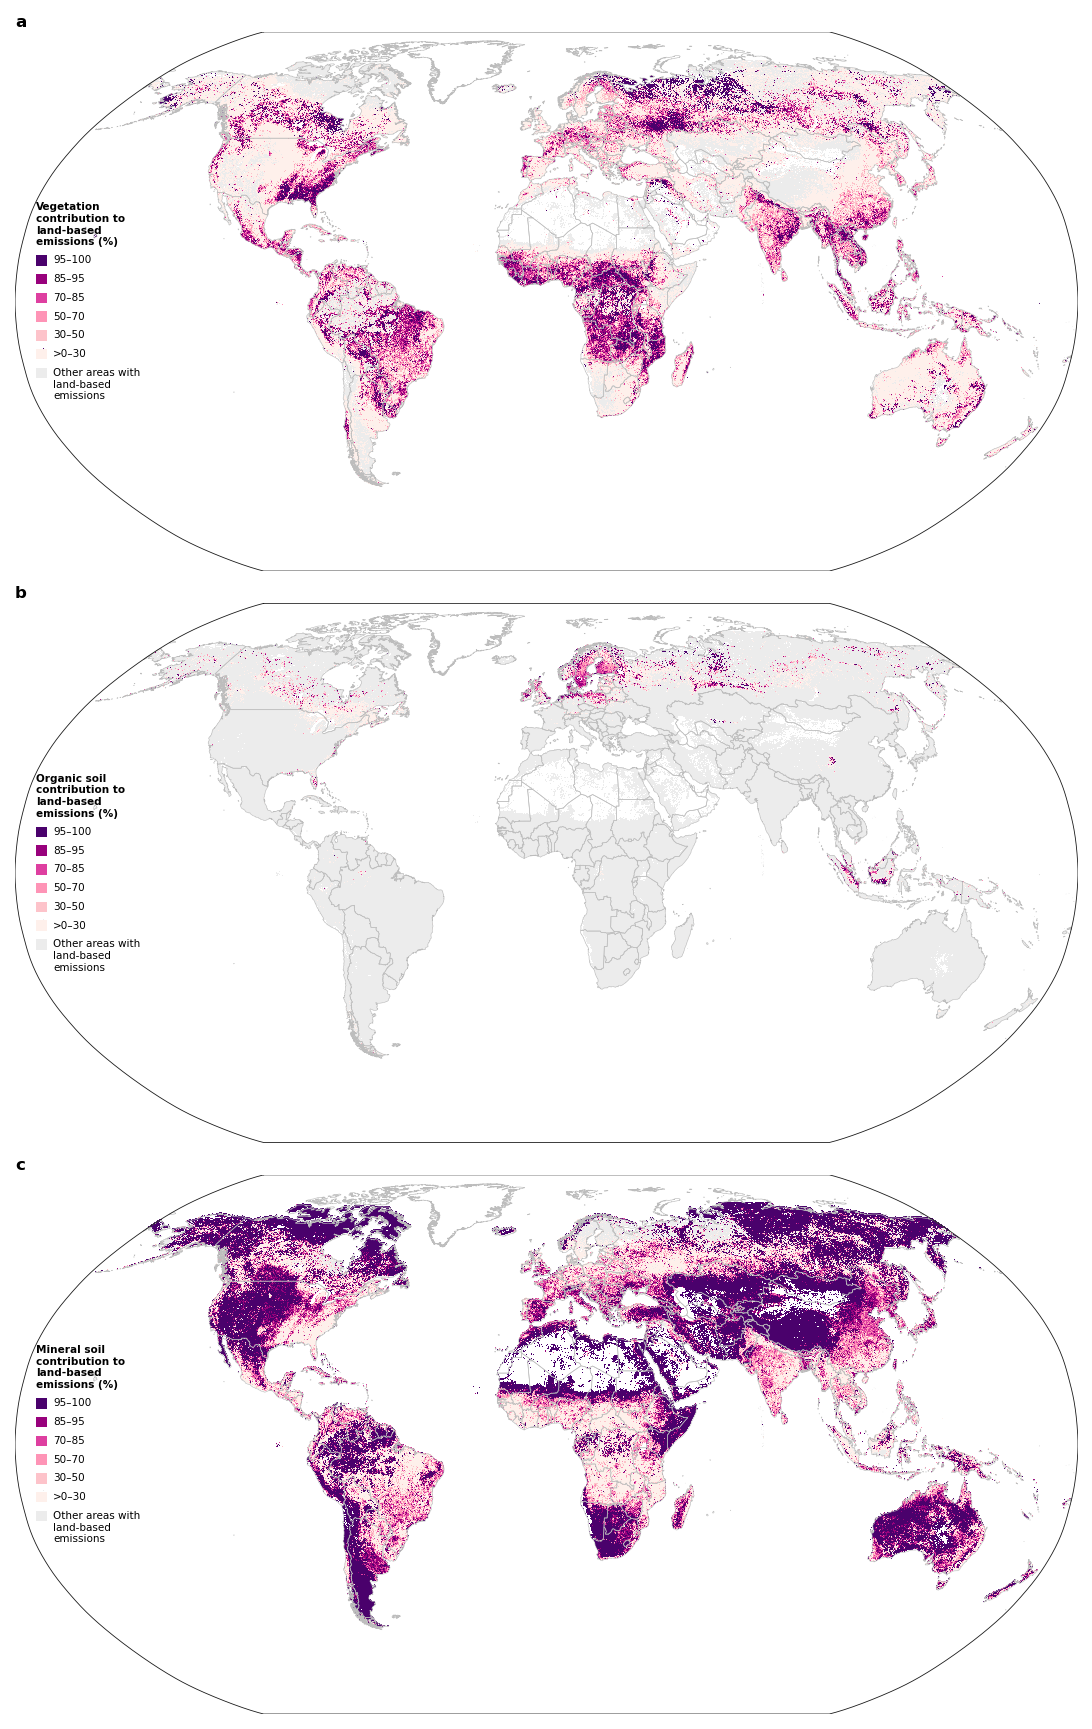

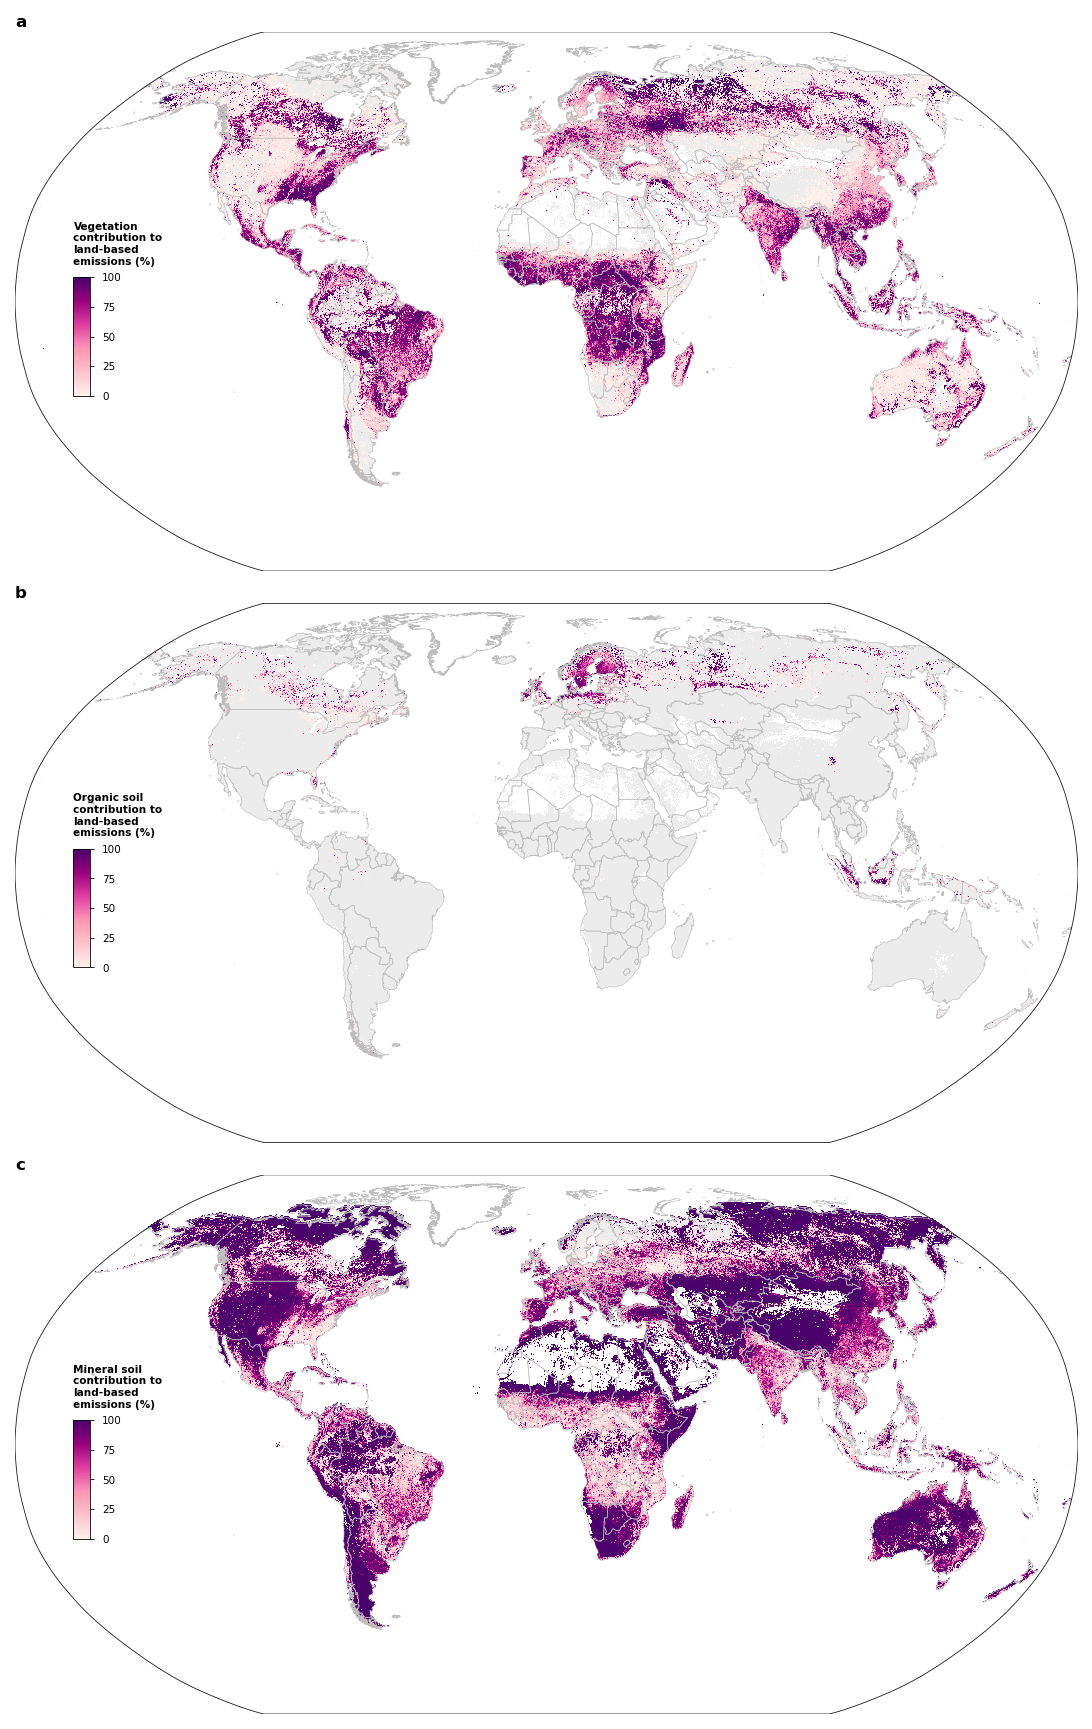

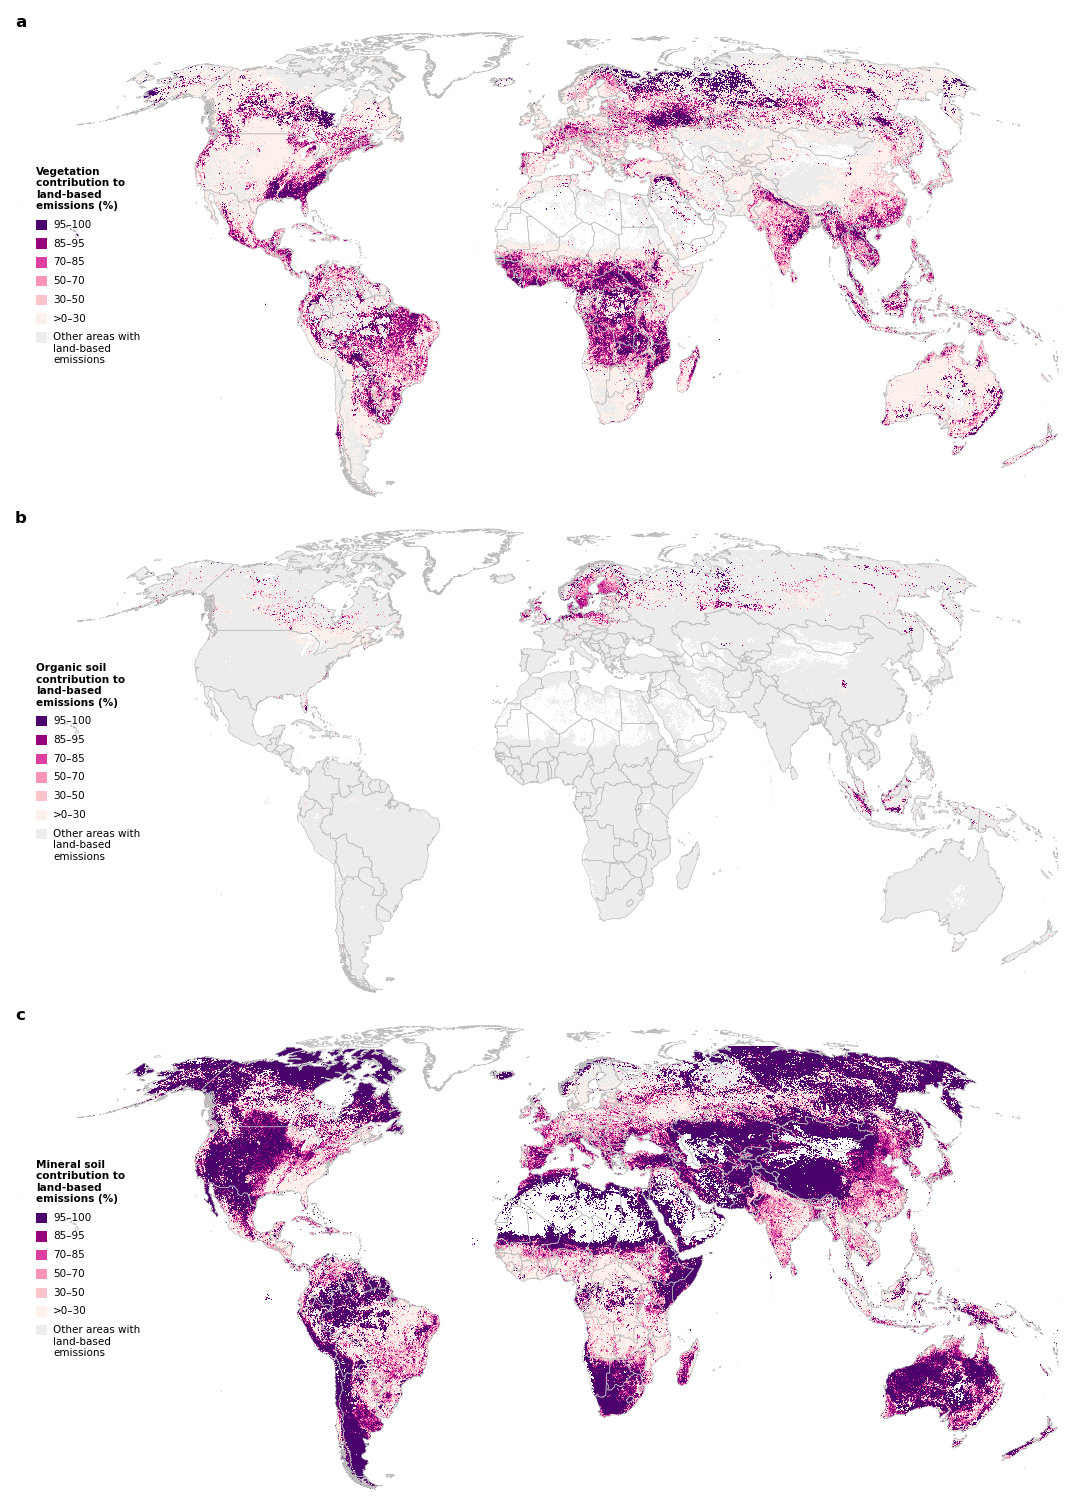

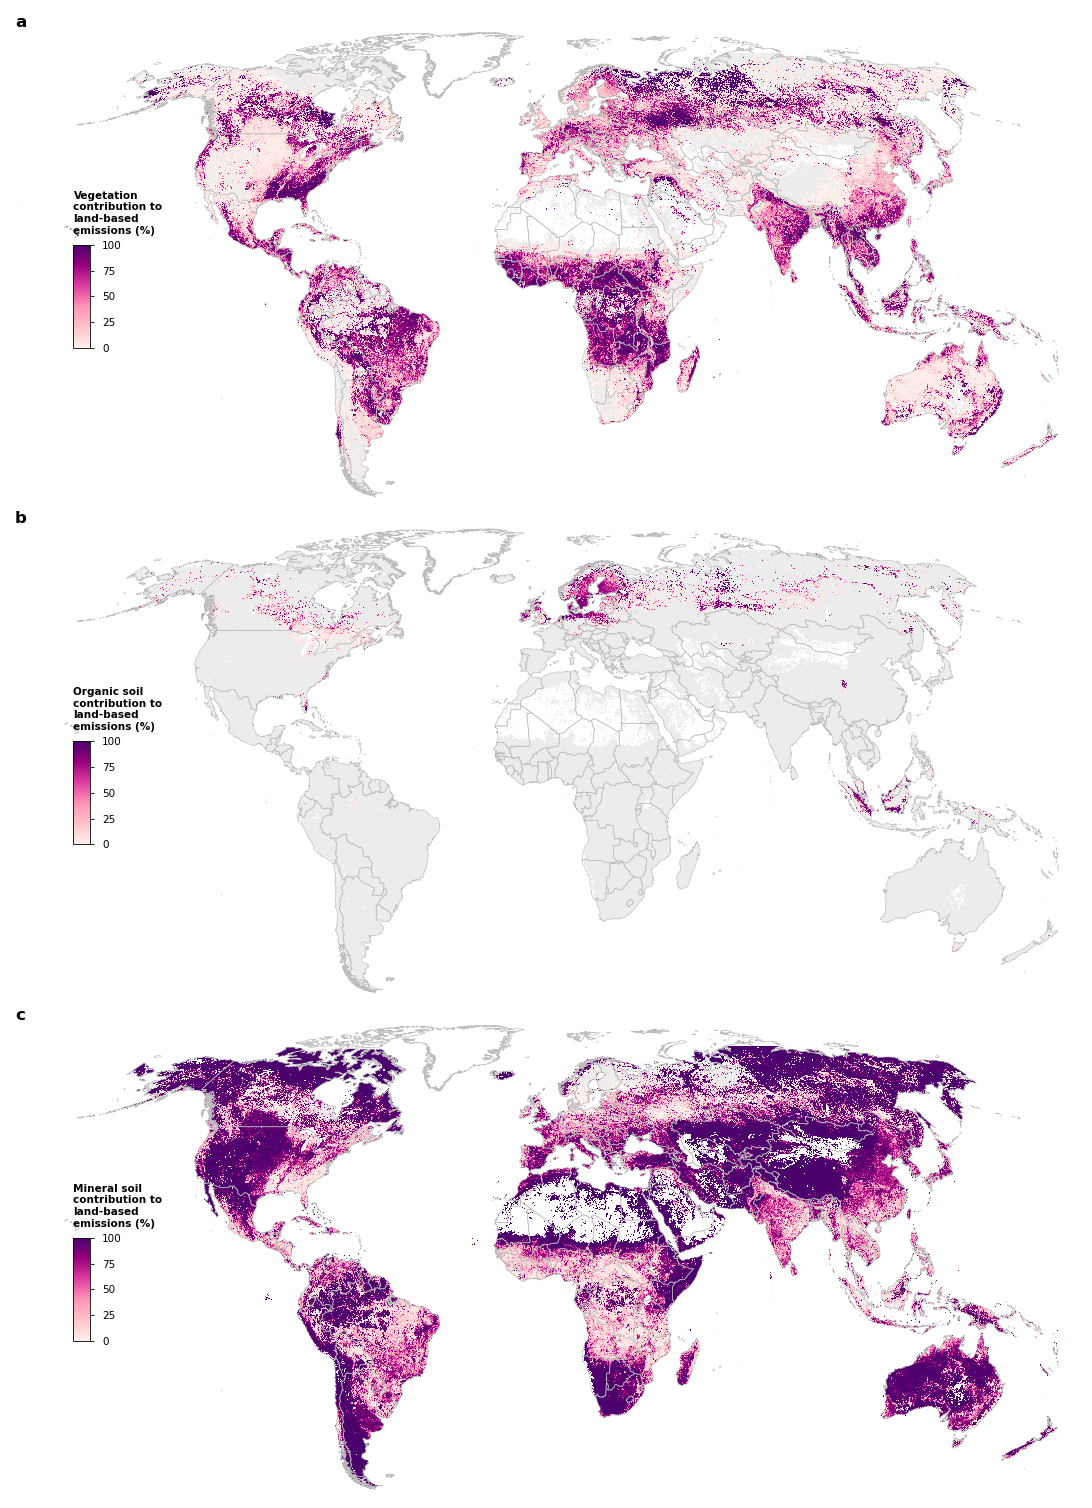

In [5]:
# --- Figure 1: three stacked Robinson component maps (120 mm @ 300 dpi) ---
# Final version made in Python script that makes LULUCF maps. 
# TODO: this figure creation shouldn't even be here anymore and should be removed in the future. Don't have time now. 
def robinson_frame(n=400):
    """Robinson projection outline (±180° meridians + ±90° parallels) in ESRI:54030."""
    tf = Transformer.from_crs("EPSG:4326", ROBINSON, always_xy=True)
    seg = [tf.transform(np.linspace(-180, 180, n), np.full(n, 90)),
           tf.transform(np.full(n, 180), np.linspace(90, -90, n)),
           tf.transform(np.linspace(180, -180, n), np.full(n, -90)),
           tf.transform(np.full(n, -180), np.linspace(-90, 90, n))]
    xs = np.concatenate([s[0] for s in seg]); ys = np.concatenate([s[1] for s in seg])
    return np.append(xs, xs[0]), np.append(ys, ys[0])

FX, FY = robinson_frame()
XLIM, YLIM = (FX.min(), FX.max()), (FY.min(), FY.max())
GRAD = LinearSegmentedColormap.from_list("rdpu_grad", BIN_COLORS); GRAD.set_bad((1, 1, 1, 0))
HAS_FLUX = np.isfinite(RASTERS["veg"][0]) | np.isfinite(RASTERS["org"][0]) | np.isfinite(RASTERS["min"][0])
BIN_LABELS_NP = [b.replace("%", "") for b in BIN_LABELS]    # bins w/o % (units shown in the title)

def legend_title(name):
    return textwrap.fill(f"{name} contribution to land-based emissions (%)", 18)

def draw_panel(ax, key, letter, name, legend="swatch", xlim=None, ylim=None, frame=True):
    raw, extent = RASTERS[key]
    xl = xlim if xlim is not None else XLIM
    yl = ylim if ylim is not None else YLIM
    other = HAS_FLUX & np.isnan(raw)           # land w/ emissions but 0% from this component -> grey
    ax.set_facecolor("white")
    if legend == "swatch":
        idx = np.digitize(raw, BIN_EDGES, right=True).astype("float32")
        idx[np.isnan(raw)] = np.nan
        idx[other] = 6                          # 'other areas'
        cmap = ListedColormap(BIN_COLORS + [LAND]); cmap.set_bad((1, 1, 1, 0))   # NaN -> white
        ax.imshow(np.ma.masked_invalid(idx), extent=extent, origin="upper",
                  cmap=cmap, vmin=-0.5, vmax=6.5, interpolation="nearest", zorder=2)
    else:
        ax.imshow(np.ma.masked_invalid(np.where(other, 1.0, np.nan)), extent=extent, origin="upper",
                  cmap=ListedColormap([LAND]), vmin=0.5, vmax=1.5, interpolation="nearest", zorder=1)
        ax.imshow(np.ma.masked_invalid(raw), extent=extent, origin="upper",
                  cmap=GRAD, vmin=0, vmax=100, interpolation="nearest", zorder=2)
    WORLD.boundary.plot(ax=ax, color=BORDER, linewidth=0.3, zorder=3)
    if frame:
        ax.plot(FX, FY, color=FRAME, linewidth=0.4, zorder=6)
    ax.set_xlim(*xl); ax.set_ylim(*yl); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.text(0.0, 1.004, letter, transform=ax.transAxes, fontsize=8, fontweight="bold", va="bottom")

    title = legend_title(name)
    if legend == "swatch":
        cols = list(reversed(BIN_COLORS)) + [LAND]
        labs = list(reversed(BIN_LABELS_NP)) + [textwrap.fill("Other areas with land-based emissions", 18)]
        top_legend(ax, cols, labs, title)
    else:
        sm = ScalarMappable(cmap=GRAD, norm=Normalize(0, 100)); sm.set_array([])
        cax = ax.inset_axes([0.055, 0.325, 0.016, 0.22])
        cb = ax.figure.colorbar(sm, cax=cax, ticks=[0, 25, 50, 75, 100])
        cb.outline.set_linewidth(0.4)
        cb.ax.tick_params(labelsize=5, length=2, width=0.4)
        ax.text(0.055, 0.565, title, transform=ax.transAxes, fontsize=5, fontweight="bold",
                va="bottom", ha="left")

def build(legend, outfile, xlim=None, ylim=None, frame=True, hspace=0.06, pad_inches=0):
    W = 180 / 25.4                                              # 180 mm wide
    A = ((xlim[1] - xlim[0]) / (ylim[1] - ylim[0])) if xlim is not None else (XLIM[1] - XLIM[0]) / (YLIM[1] - YLIM[0])
    H = (W / A) * (3 + 2 * hspace) / 0.98                       # panels fill the full width
    with mpl.rc_context({"font.size": 5}):
        fig, axes = plt.subplots(3, 1, figsize=(W, H), dpi=150)
        fig.patch.set_facecolor("white")
        for ax, p in zip(axes, PANELS):
            draw_panel(ax, p["key"], p["letter"], p["name"], legend=legend, xlim=xlim, ylim=ylim, frame=frame)
        fig.subplots_adjust(left=0, right=1, top=0.99, bottom=0.01, hspace=hspace)
        fig.savefig(outfile, dpi=300, bbox_inches="tight", pad_inches=pad_inches, facecolor="white")
    print("saved", outfile)
    return fig

_tf = Transformer.from_crs("EPSG:4326", ROBINSON, always_xy=True)
ZX = (_tf.transform(-173, 0)[0], _tf.transform(173, 0)[0])     # trim Pacific
ZY = (_tf.transform(0, -57)[1], _tf.transform(0, 84)[1])       # drop Antarctica

# # Oscar designed four options for this figure (with and without globe outline, with gradient or categorical legend). 
# # We're only using the one without globe outline and with categorical legend.
# build("swatch",   "LULUCF100_maps__fig1_components.png")
# build("colorbar", "LULUCF100_maps__fig1_components_gradient.png")
build("swatch",   "LULUCF100_maps__fig1_components_zoom.png",          xlim=ZX, ylim=ZY, frame=False, pad_inches=0.15)
# build("colorbar", "LULUCF100_maps__fig1_components_gradient_zoom.png", xlim=ZX, ylim=ZY, frame=False)
plt.show()

## Figure 2 — areas contributing to the top 50% / 50–80% of flux

Per-pixel cumulative-contribution (Lorenz) classification of the 0.04° avg-2016–2024 gross **emissions** and **removals** rasters: rank land pixels by per-ha intensity (|flux|/area), take those summing to the top **50%** of total flux, then the next **30%** (50–80%). Reproject the class raster to Robinson and map it (dark = top 50%, light = 50–80%, grey = other land GHG fluxes).

In [8]:
# --- Classify top-50% / 50-80% areas using the CSV's area-fraction cutoffs ---
import pandas as pd

GRAY_LAND = "#e8e7e4"                                                       # "other areas with land GHG fluxes"
CONTRIB_PANELS = [
    {"key": "removals", "unit": "removals", "dark": "#2c928a", "light": "#8cd2c7",
     "file": "LULUCF_gross_removals__all_C_pools__MgCO2_0_04deg_yr_v1_0_0_avg_2016_2024_global_reproj.tif"},
    {"key": "emissions", "unit": "emissions", "dark": "#844803", "light": "#ebd9af",
     "file": "LULUCF_gross_emissions__all_C_pools__all_gases__MgCO2e_0_04deg_yr_v1_0_0_avg_2016_2024_global_reproj.tif"},
]

# Cutoffs from the native-resolution Lorenz curve CSV: area fraction at 50% and 80% of flux
LZ = pd.read_csv(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v1_0_0__veg_v1_0_5__minsoil_v1_0_1__orgsoil_v1_0_1/lorenz_curves__Global_avg_2016_2024.csv')
def csv_cutoffs(col):
    return (float(np.interp(0.50, LZ[col], LZ["cum_area_frac"])),
            float(np.interp(0.80, LZ[col], LZ["cum_area_frac"])))
CUTOFFS = {"emissions": csv_cutoffs("emis_cum_flux_frac_global"),
           "removals":  csv_cutoffs("remv_cum_flux_frac_global")}
rnd = lambda x: int(np.floor(x * 100 + 0.5))                                # round-half-up to integer %

def classify_flux(path, a50, a80):
    """Class raster (1=top 50%, 2=50-80%, 3=other-flux, NaN=no data).
    Expects an already-Robinson-projected file; uses equal pixel area weighting."""
    with rasterio.open(path) as s:
        v = s.read(1).astype("float64")
        bounds = s.bounds
    extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    valid = np.isfinite(v) & (v != 0)
    ij = np.where(valid)
    mag = np.abs(v[valid])
    order = np.argsort(mag)[::-1]                               # rank by intensity desc
    n = order.size
    af = np.arange(1, n + 1) / n                                # equal-area cumulative fraction
    i50 = int(np.searchsorted(af, a50)); i80 = int(np.searchsorted(af, a80))
    cls = np.full(n, np.nan); cls[:i50 + 1] = 1; cls[i50 + 1:i80 + 1] = 2; cls[i80 + 1:] = 3
    out = np.full(v.shape, np.nan, "float32"); out[ij[0][order], ij[1][order]] = cls
    return out, extent

def to_robinson(arr, src_transform, src_crs, w=2126):
    """Reproject a class raster to Robinson (nearest, no dilation -> proportions preserved).
    w ~ matches the 300-dpi export width so each data pixel stays small/crisp like QGIS."""
    left, right, bottom, top = float(FX.min()), float(FX.max()), float(FY.min()), float(FY.max())
    res = (right - left) / w; h = int(round((top - bottom) / res))
    dst_transform = Affine.translation(left, top) * Affine.scale(res, -res)
    dst = np.full((h, w), np.nan, "float32")
    reproject(arr, dst, src_transform=src_transform, src_crs=src_crs,
              dst_transform=dst_transform, dst_crs=ROBINSON,
              src_nodata=np.nan, dst_nodata=np.nan, resampling=Resampling.nearest)
    return dst, (left, right, bottom, top)

CONTRIB = {}
for p in CONTRIB_PANELS:
    a50, a80 = CUTOFFS[p["key"]]
    dst, extent = classify_flux(f"{RASTER_DIR}{p['file']}", a50, a80)
    p50, p80 = rnd(a50), rnd(a80)
    CONTRIB[p["key"]] = {"dst": dst, "extent": extent, "land50": p50, "land3080": p80 - p50}
    print(f"{p['key']}: top-50% -> {p50}% of land | 50-80% -> {p80 - p50}% (CSV cutoffs)")

removals: top-50% -> 19% of land | 50-80% -> 28% (CSV cutoffs)
emissions: top-50% -> 5% of land | 50-80% -> 16% (CSV cutoffs)


saved LULUCF100_maps__fig2_contrib_removals.png
saved LULUCF100_maps__fig2_contrib_emissions.png


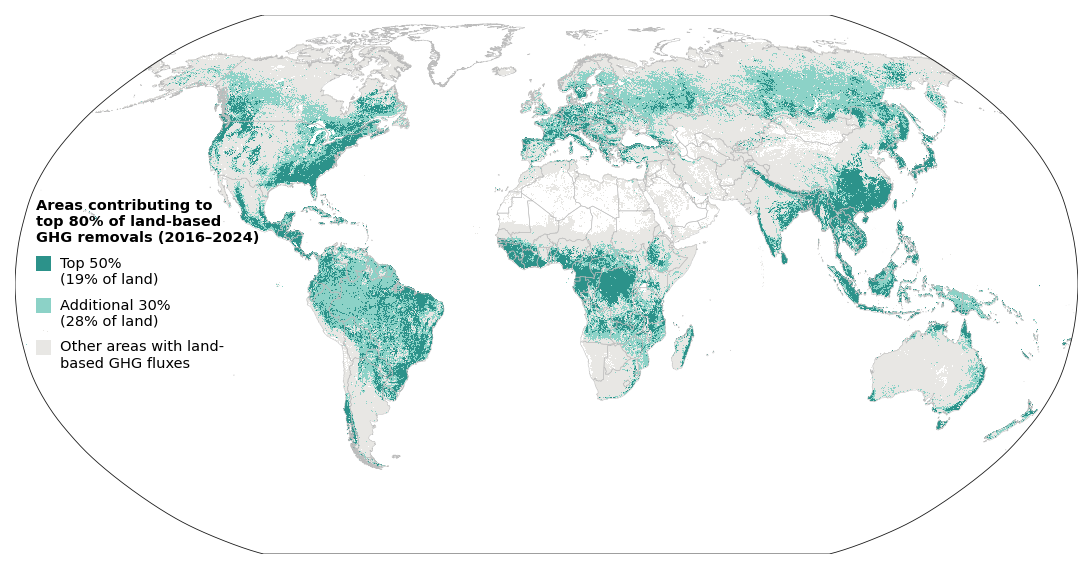

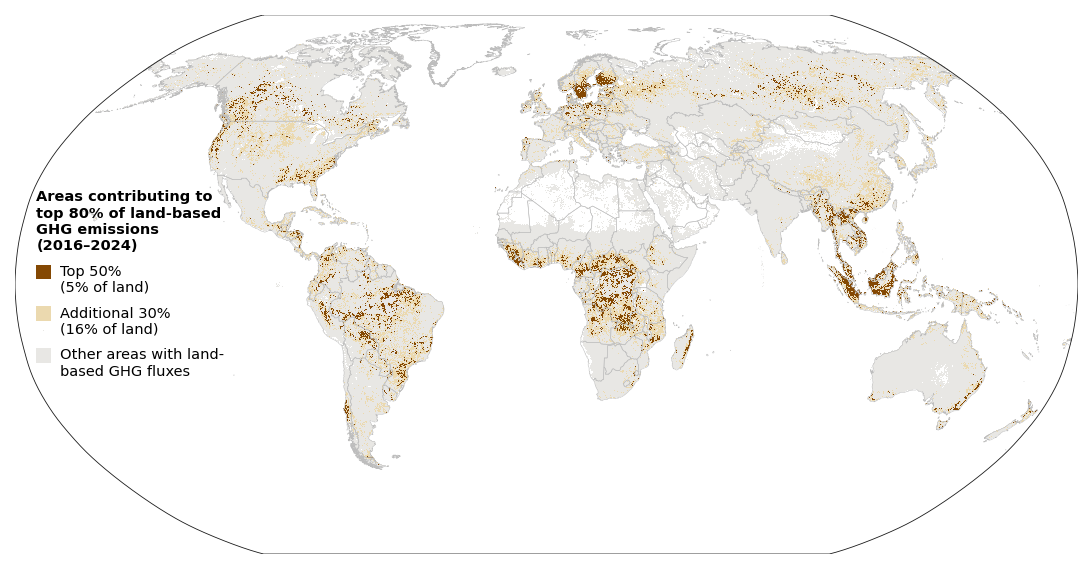

In [20]:
# --- Figure 2: contribution maps (one per flux direction), 180 mm @ 300 dpi ---
ASPECT = (XLIM[1] - XLIM[0]) / (YLIM[1] - YLIM[0])

def draw_contrib(ax, key, unit, dark, light, wrap=24, show_other=True, xlim=None, ylim=None, frame=True,
                 legend_loc="center left", legend_anchor=(0.02, 0.5)):
    d = CONTRIB[key]
    xl = xlim if xlim is not None else XLIM
    yl = ylim if ylim is not None else YLIM
    ax.set_facecolor("white")
    cmap = ListedColormap([dark, light, GRAY_LAND]); cmap.set_bad((1, 1, 1, 0))  # NaN(no tiff data)->white
    ax.imshow(np.ma.masked_invalid(d["dst"]), extent=d["extent"], origin="upper",
              cmap=cmap, vmin=0.5, vmax=3.5, interpolation="nearest", zorder=2)
    WORLD.boundary.plot(ax=ax, color=BORDER, linewidth=0.25, zorder=3)
    if frame:
        ax.plot(FX, FY, color=FRAME, linewidth=0.4, zorder=6)
    ax.set_xlim(*xl); ax.set_ylim(*yl); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    labels = [f"Top 50%\n({d['land50']:.0f}% of land)",
              f"Additional 30%\n({d['land3080']:.0f}% of land)",
              textwrap.fill("Other areas with land-based GHG fluxes", wrap)]
    title = textwrap.fill(f"Areas contributing to top 80% of land-based GHG {unit} (2016\u20132024)", wrap)
    cols = [dark, light, GRAY_LAND]
    if not show_other:
        labels, cols = labels[:2], cols[:2]
    top_legend(ax, cols, labels, title, loc=legend_loc, bbox_to_anchor=legend_anchor)

for p in CONTRIB_PANELS:
    fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_W_IN / ASPECT), dpi=150)
    fig.patch.set_facecolor("white")
    draw_contrib(ax, p["key"], p["unit"], p["dark"], p["light"])
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    out = f"LULUCF100_maps__fig2_contrib_{p['key']}.png"
    # fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_emissions_removals_50_80_percent_{today}.jpg', dpi=300, facecolor="white")
    # print("saved", out)
plt.show()

## Figure 3 — overlap of the top-50% removal and emission areas

Combine the top-50% class of removals and emissions per pixel: **teal** = removals only, **brown** = emissions only, **black** = both, **grey** = other land with GHG flux, white = no data.

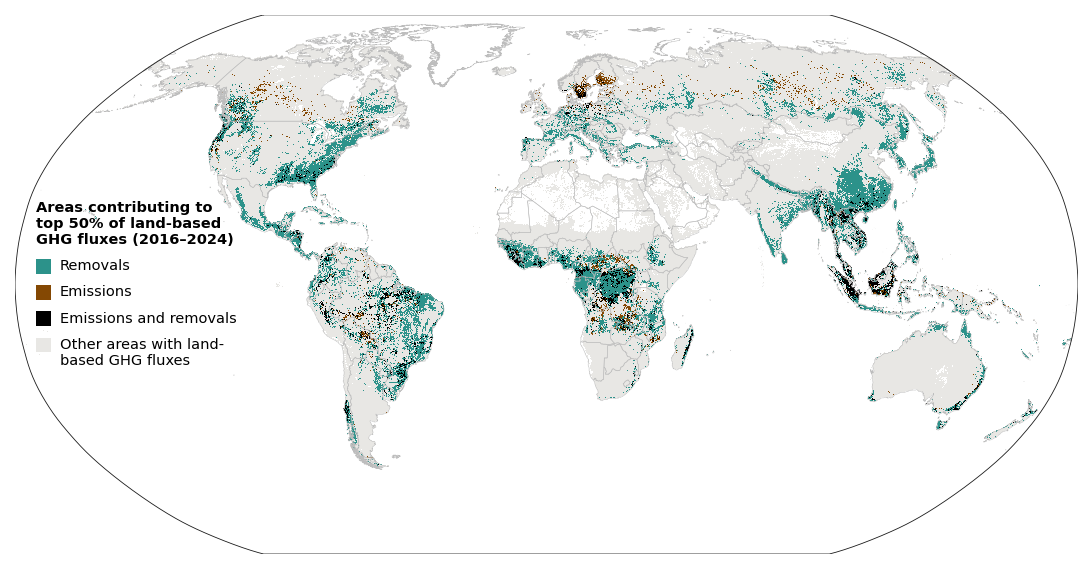

In [21]:
# --- Figure 3: top-50% removal & emission overlap, 180 mm @ 300 dpi ---
rem, emis = CONTRIB["removals"], CONTRIB["emissions"]
rc, ec = rem["dst"], emis["dst"]          # already Robinson-projected
rem_top, emis_top = (rc == 1), (ec == 1)
has = np.isfinite(rc) | np.isfinite(ec)
comb = np.full(rc.shape, np.nan, "float32")
comb[has] = 4
comb[rem_top & ~emis_top] = 1
comb[emis_top & ~rem_top] = 2
comb[rem_top & emis_top]  = 3
dst, extent = comb, rem["extent"]

OV_COLORS = ["#2c928a", "#844803", "#000000", GRAY_LAND]       # removals, emissions, both, other
OV_LABELS = ["Removals", "Emissions", "Emissions and removals",
             textwrap.fill("Other areas with land-based GHG fluxes", 24)]
ASPECT = (XLIM[1] - XLIM[0]) / (YLIM[1] - YLIM[0])

fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_W_IN / ASPECT), dpi=150)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
cmap = ListedColormap(OV_COLORS); cmap.set_bad((1, 1, 1, 0))   # NaN(no data)->white
ax.imshow(np.ma.masked_invalid(dst), extent=extent, origin="upper",
          cmap=cmap, vmin=0.5, vmax=4.5, interpolation="nearest", zorder=2)
WORLD.boundary.plot(ax=ax, color=BORDER, linewidth=0.25, zorder=3)
ax.plot(FX, FY, color=FRAME, linewidth=0.4, zorder=6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)
title = textwrap.fill("Areas contributing to top 50% of land-based GHG fluxes (2016\u20132024)", 24)
top_legend(ax, OV_COLORS, OV_LABELS, title)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
# fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_emissions_removals_overlap_50_percent_{today}.jpg', dpi=300, facecolor="white")
# print("saved LULUCF100_maps__fig3_top50_overlap.png")
plt.show()

## Figure 4 — combined panel (Lorenz + 50% overlap / removals / emissions)

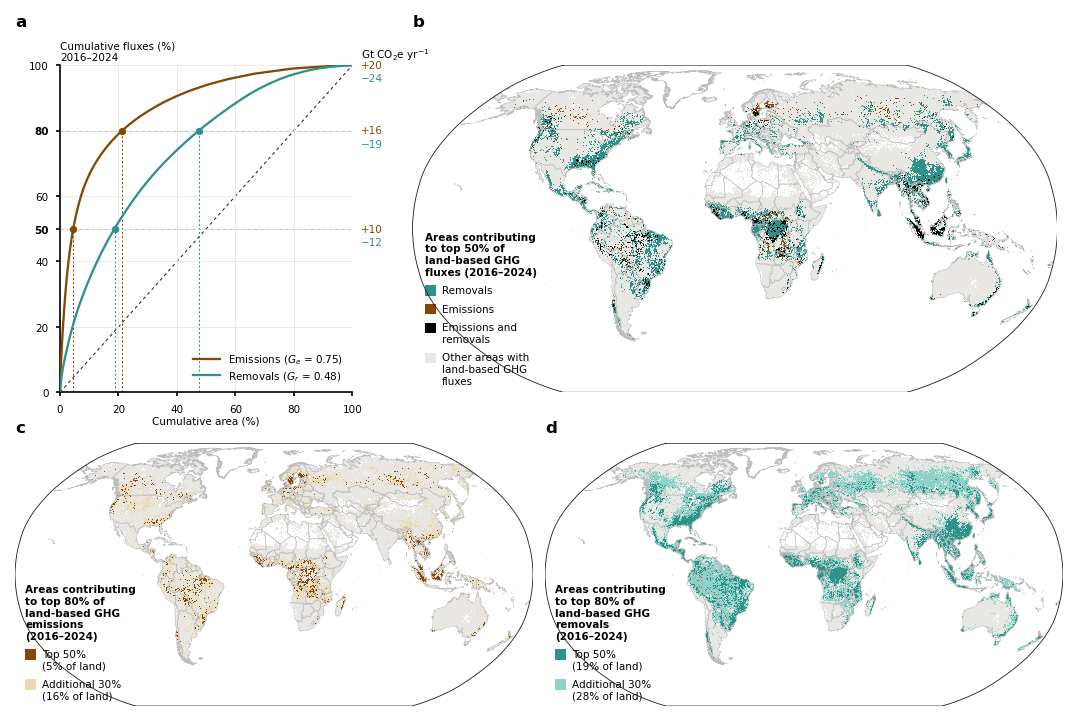

In [27]:
# --- Figure 4: 4-panel composite, 180 mm @ 300 dpi (others font 5, labels bold 8) ---
# Not actually using this version in the paper (but it includes some code that the version in the paper uses). 
# TODO remove, or at least make it not necessary for the version used in the paper
from matplotlib.lines import Line2D
EMIS_D, REMV_D = "#844803", "#2c928a"

def draw_overlap(ax, xlim=None, ylim=None, frame=True,
                 legend_loc="center left", legend_anchor=(0.02, 0.5)):
    xl = xlim if xlim is not None else XLIM
    yl = ylim if ylim is not None else YLIM
    rem, emis = CONTRIB["removals"], CONTRIB["emissions"]
    rc, ec = rem["dst"], emis["dst"]          # already Robinson-projected
    rt, et = (rc == 1), (ec == 1)
    hasf = np.isfinite(rc) | np.isfinite(ec)
    comb = np.full(rc.shape, np.nan, "float32")
    comb[hasf] = 4; comb[rt & ~et] = 1; comb[et & ~rt] = 2; comb[rt & et] = 3
    dst, extent = comb, rem["extent"]
    ax.set_facecolor("white")
    cmap = ListedColormap([REMV_D, EMIS_D, "#000000", GRAY_LAND]); cmap.set_bad((1, 1, 1, 0))
    ax.imshow(np.ma.masked_invalid(dst), extent=extent, origin="upper", cmap=cmap,
              vmin=0.5, vmax=4.5, interpolation="nearest", zorder=2)
    WORLD.boundary.plot(ax=ax, color=BORDER, linewidth=0.25, zorder=3)
    if frame:
        ax.plot(FX, FY, color=FRAME, linewidth=0.4, zorder=6)
    ax.set_xlim(*xl); ax.set_ylim(*yl); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    labels = ["Removals", "Emissions", textwrap.fill("Emissions and removals", 18),
              textwrap.fill("Other areas with land-based GHG fluxes", 18)]
    title = textwrap.fill("Areas contributing to top 50% of land-based GHG fluxes (2016–2024)", 18)
    top_legend(ax, [REMV_D, EMIS_D, "#000000", GRAY_LAND], labels, title, loc=legend_loc, bbox_to_anchor=legend_anchor)

def draw_lorenz(ax):
    a = LZ["cum_area_frac"].values * 100
    ce = LZ["emis_cum_flux_frac_global"].values * 100
    cr = LZ["remv_cum_flux_frac_global"].values * 100
    Et = LZ["emis_cum_flux_GtCO2e_global"].values[-1]
    Rt = LZ["remv_cum_flux_GtCO2e_global"].values[-1]
    (e50, e80) = [v * 100 for v in CUTOFFS["emissions"]]
    (r50, r80) = [v * 100 for v in CUTOFFS["removals"]]

    # Gini coefficients from the Lorenz curves. Need to flip sign because the curves are above the 1:1 line rather than below
    ge = 2 * np.trapezoid(ce / 100, a / 100) - 1
    gr = 2 * np.trapezoid(cr / 100, a / 100) - 1

    ax.grid(True, color="#e6e6e6", lw=0.4, zorder=0)
    ax.plot([0, 100], [0, 100], ls=(0, (3, 3)), color="#222", lw=0.5, zorder=1)
    for y in (50, 80): ax.plot([0, 100], [y, y], ls=(0, (3, 3)), color="#222", lw=0.5, zorder=1)
    for x, y in [(e50, 50), (e80, 80)]: ax.plot([x, x], [0, y], ls=(0, (2, 2)), color=EMIS_D, lw=0.5, zorder=1)
    for x, y in [(r50, 50), (r80, 80)]: ax.plot([x, x], [0, y], ls=(0, (2, 2)), color=REMV_D, lw=0.5, zorder=1)
    ax.plot(a, ce, color=EMIS_D, lw=1.1, zorder=4)
    ax.plot(a, cr, color=REMV_D, lw=1.1, zorder=4)
    for x, y in [(e50, 50), (e80, 80)]: ax.plot(x, y, "o", color=EMIS_D, ms=2.5, zorder=5)
    for x, y in [(r50, 50), (r80, 80)]: ax.plot(x, y, "o", color=REMV_D, ms=2.5, zorder=5)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 50, 60, 80, 100])
    for t in ax.get_yticklabels():
        if t.get_text() in ("50", "80"): t.set_fontweight("bold")
    ax.set_xticks([0, 20, 40, 60, 80, 100])
    ax.text(50, -7, "Cumulative area (%)", ha="center", va="top")
    ax.text(0, 101, "Cumulative fluxes (%)\n2016–2024", va="bottom", ha="left", linespacing=1.1)
    ax.text(103, 101, "Gt CO$_2$e yr$^{-1}$", va="bottom", ha="left")
    for y in (50, 80, 100):
        ax.text(103, y, f"+{round(Et * y / 100)}", color=EMIS_D, va="center", ha="left")
        ax.text(103, y - 4, f"−{round(Rt * y / 100)}", color=REMV_D, va="center", ha="left")
    leg_h = [Line2D([0], [0], color=EMIS_D, lw=1.1, label=f"Emissions ($G_e$ = {ge:.2f})"),
             Line2D([0], [0], color=REMV_D, lw=1.1, label=f"Removals ($G_r$ = {gr:.2f})")]
    ax.legend(handles=leg_h, loc="lower right", frameon=False, fontsize=5,
              handlelength=2.6, labelspacing=0.3, borderaxespad=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=2)
    
# --- layout (inches) ---
W = FIG_W_IN; A = ASPECT
mL, mR, mT, mB = 0.05, 0.05, 0.38, 0.10
gL, gxt, gxb, gy = 0.30, 0.40, 0.08, 0.34
usable = W - mL - mR
cw = (usable - gxb) / 2; ch = cw / A
aw = 1.95; bw = 4.30; bh = bw / A; ah = bh
H = mT + bh + gy + ch + mB
r0b = mB + ch + gy; r1b = mB
a_left = mL + gL
rect_a = [a_left / W, r0b / H, aw / W, ah / H]
rect_b = [(a_left + aw + gxt) / W, r0b / H, bw / W, bh / H]
rect_c = [mL / W, r1b / H, cw / W, ch / H]
rect_d = [(mL + cw + gxb) / W, r1b / H, cw / W, ch / H]

with mpl.rc_context({"font.size": 5}):
    fig = plt.figure(figsize=(W, H), dpi=150); fig.patch.set_facecolor("white")
    draw_lorenz(fig.add_axes(rect_a))
    draw_overlap(fig.add_axes(rect_b), legend_loc="lower left", legend_anchor=(0.02, 0.02))
    draw_contrib(fig.add_axes(rect_c), "emissions", "emissions", EMIS_D, "#ebd9af", wrap=18, show_other=False, legend_loc="lower left", legend_anchor=(0.02, 0.02))
    draw_contrib(fig.add_axes(rect_d), "removals", "removals", REMV_D, "#8cd2c7", wrap=18, show_other=False, legend_loc="lower left", legend_anchor=(0.02, 0.02))
    off = 0.24 / H
    fig.text(mL / W,       rect_a[1] + rect_a[3] + off,  "a", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.text(rect_b[0],    rect_b[1] + rect_b[3] + off,  "b", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.text(mL / W,       rect_c[1] + rect_c[3] + 0.012, "c", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.text(rect_d[0],    rect_d[1] + rect_d[3] + 0.012, "d", fontsize=8, fontweight="bold", va="bottom", ha="left")
    # fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_emissions_removals_multipanel_with_globe_{today}.jpg', dpi=300, facecolor="white")
    # print("saved fig", (round(W * 300), round(H * 300)))
plt.show()

## Figure 4b — zoomed, frameless variant (Antarctica cropped, smaller Pacific)
Version actually used in the paper. This is what I need to integrate with the separate curve creation notebook and not need all the other baggage in this notebook.

saved fig  aspect 2.27 (2126, 1265)


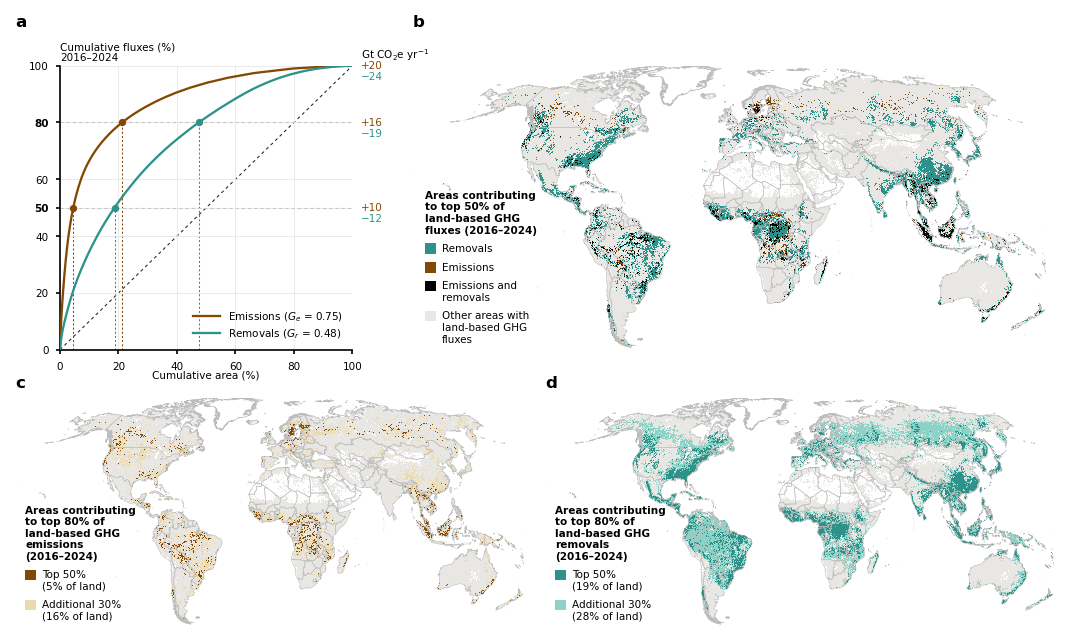

In [28]:
# --- Figure 4b: zoomed variant of fig 4 (no outer frame, cropped) ---
_tf = Transformer.from_crs("EPSG:4326", ROBINSON, always_xy=True)
ZX = (_tf.transform(-173, 0)[0], _tf.transform(173, 0)[0])     # trim Pacific edges
ZY = (_tf.transform(0, -57)[1], _tf.transform(0, 84)[1])       # drop Antarctica, keep N land
AZ = (ZX[1] - ZX[0]) / (ZY[1] - ZY[0])

W = FIG_W_IN
mL, mR, mT, mB = 0.05, 0.05, 0.38, 0.10
gL, gxt, gxb, gy = 0.30, 0.40, 0.08, 0.32
usable = W - mL - mR
cw = (usable - gxb) / 2; ch = cw / AZ
aw = 1.95; bw = 4.30; bh = bw / AZ; ah = bh
H = mT + bh + gy + ch + mB
r0b = mB + ch + gy; r1b = mB
a_left = mL + gL
rect_a = [a_left / W, r0b / H, aw / W, ah / H]
rect_b = [(a_left + aw + gxt) / W, r0b / H, bw / W, bh / H]
rect_c = [mL / W, r1b / H, cw / W, ch / H]
rect_d = [(mL + cw + gxb) / W, r1b / H, cw / W, ch / H]

with mpl.rc_context({"font.size": 5}):
    fig = plt.figure(figsize=(W, H), dpi=150); fig.patch.set_facecolor("white")
    draw_lorenz(fig.add_axes(rect_a))
    draw_overlap(fig.add_axes(rect_b), xlim=ZX, ylim=ZY, frame=False, legend_loc="lower left", legend_anchor=(0.02, 0.02))
    draw_contrib(fig.add_axes(rect_c), "emissions", "emissions", EMIS_D, "#ebd9af",
                 wrap=18, show_other=False, xlim=ZX, ylim=ZY, frame=False, legend_loc="lower left", legend_anchor=(0.02, 0.02))
    draw_contrib(fig.add_axes(rect_d), "removals", "removals", REMV_D, "#8cd2c7",
                 wrap=18, show_other=False, xlim=ZX, ylim=ZY, frame=False, legend_loc="lower left", legend_anchor=(0.02, 0.02))
    off = 0.24 / H
    fig.text(mL / W,    rect_a[1] + rect_a[3] + off,  "a", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.text(rect_b[0], rect_b[1] + rect_b[3] + off,  "b", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.text(mL / W,    rect_c[1] + rect_c[3] + 0.012, "c", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.text(rect_d[0], rect_d[1] + rect_d[3] + 0.012, "d", fontsize=8, fontweight="bold", va="bottom", ha="left")
    fig.savefig(f'{LULUCF_zonal_stats_folder_figures}/LULUCF_emissions_removals_multipanel_no_globe_for_paper_{today}.jpg', dpi=300, facecolor="white")
    print("saved fig  aspect", round(AZ, 3), (round(W * 300), round(H * 300)))
plt.show()